# Model Deployment - Mid Exam
**Video Presentasi:** [URL VIDEO ANDA DI SINI]

**NIM:** [NIM ANDA]

**Dataset:** A (NIM Ganjil) - Fitur dan Target dipisah dalam file berbeda

## 1. Import Libraries
Memuat seluruh library yang diperlukan untuk analisis, pemodelan, dan visualisasi.

In [1]:
# ========================================
# 1. IMPORT LIBRARIES
# ========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("LIBRARIES LOADED SUCCESSFULLY")
print("=" * 50)

LIBRARIES LOADED SUCCESSFULLY


## 2. Load Dataset
Dataset A memisahkan fitur dan target dalam file berbeda. Kita menggabungkan keduanya menggunakan kolom `Student_ID` sebagai primary key.

In [2]:
# ========================================
# 2. LOAD DATASET (Dataset A - Separated Files)
# ========================================
df_features = pd.read_csv('../data/A.csv')
df_targets = pd.read_csv('../data/A_targets.csv')

print("=" * 50)
print("RAW FILES LOADED")
print("=" * 50)
print(f"Features Shape: {df_features.shape}")
print(f"Targets Shape : {df_targets.shape}")

# Merge on Student_ID
df = pd.merge(df_features, df_targets, on='Student_ID')

print(f"\nMerged Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("")

RAW FILES LOADED
Features Shape: (5000, 23)
Targets Shape : (5000, 3)

Merged Dataset Shape: (5000, 25)
Rows: 5000, Columns: 25



## 3. Exploratory Data Analysis
Memeriksa struktur data, tipe kolom, statistik deskriptif, dan missing values.

In [3]:
# ========================================
# 3. INITIAL DATA INSPECTION
# ========================================
print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
df.head()


FIRST 5 ROWS


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [4]:
print("\n" + "=" * 50)
print("DATASET INFO")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  apti

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


In [5]:
print("\n" + "=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print("\n" + "=" * 50)
print("DUPLICATE ROWS CHECK")
print("=" * 50)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")


MISSING VALUES CHECK
                             Count  Percentage
extracurricular_involvement   1006       20.12

DUPLICATE ROWS CHECK
Duplicate rows: 0


**Temuan:** Kolom `extracurricular_involvement` memiliki ~1006 missing values (~20.12%). Kita akan mengisi missing values dengan modus karena kolom ini bersifat ordinal kategorikal.

## 4. Target Variable Analysis
Analisis distribusi kedua variabel target: `placement_status` (Klasifikasi) dan `salary_lpa` (Regresi).


TARGET VARIABLE DISTRIBUTION

Placement Status:
placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

Salary (LPA) Statistics:
count    5000.000000
mean       13.897180
std         6.247481
min         0.000000
25%        12.510000
50%        15.760000
75%        18.332500
max        20.000000
Name: salary_lpa, dtype: float64


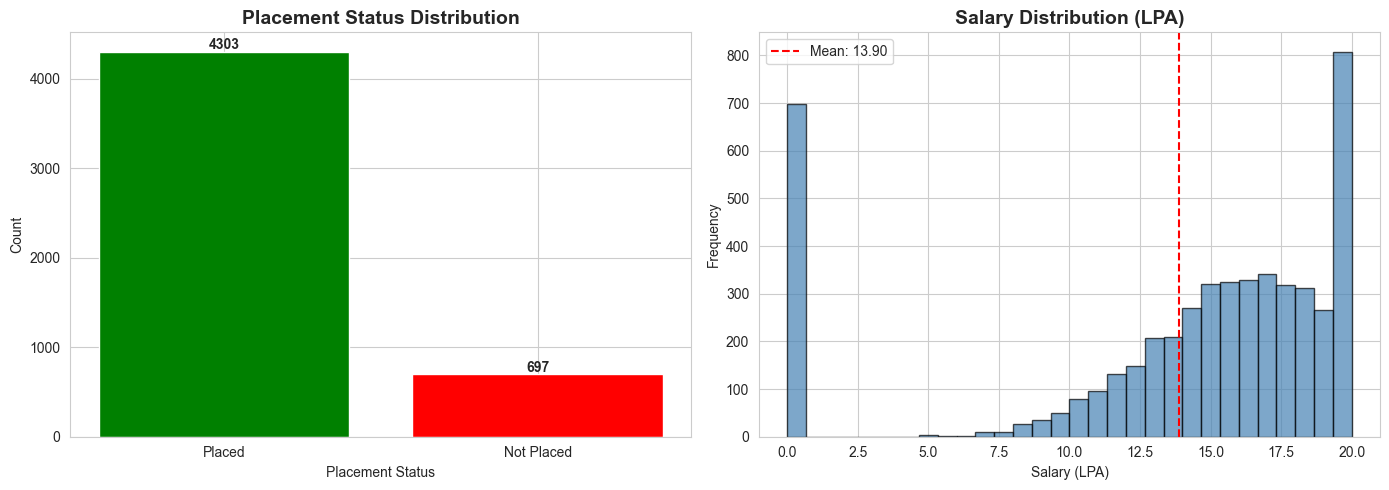

In [ ]:
# ========================================
# 4. TARGET VARIABLE ANALYSIS
# ========================================
sns.set_style('whitegrid')

print("\n" + "=" * 50)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 50)
print("\nPlacement Status:")
print(df['placement_status'].value_counts())
print(f"\nSalary (LPA) Statistics:")
print(df['salary_lpa'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification Target
target_counts = df['placement_status'].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=['green', 'red'])
axes[0].set_title('Placement Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Placement Status')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Regression Target
axes[1].hist(df['salary_lpa'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Salary Distribution (LPA)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Salary (LPA)')
axes[1].axvline(df['salary_lpa'].mean(), color='red', linestyle='--', label=f"Mean: {df['salary_lpa'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Correlation Analysis
Analisis korelasi antar fitur numerik untuk memahami hubungan antar variabel dan mengidentifikasi multikolinearitas.


CORRELATION MATRIX


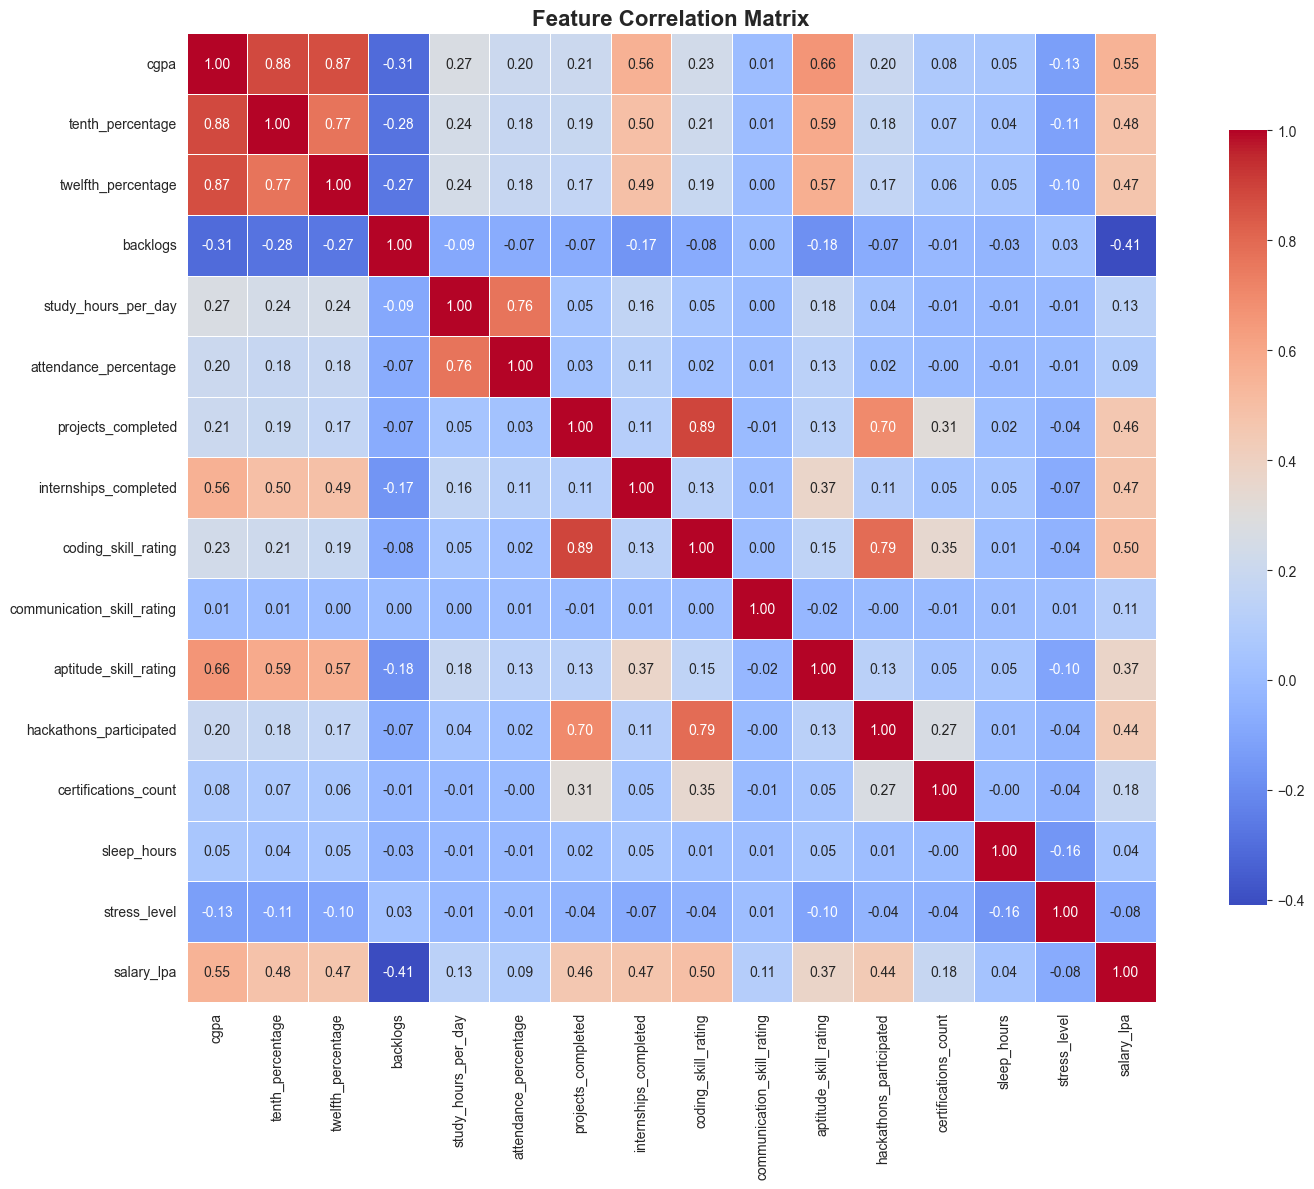


Top correlations with salary_lpa:
cgpa                       0.549533
coding_skill_rating        0.496776
tenth_percentage           0.481920
twelfth_percentage         0.471026
internships_completed      0.469054
projects_completed         0.456588
hackathons_participated    0.438845
backlogs                   0.410192
aptitude_skill_rating      0.372738
certifications_count       0.180561
Name: salary_lpa, dtype: float64


In [ ]:
# ========================================
# 5. CORRELATION ANALYSIS
# ========================================
print("\n" + "=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Student_ID']

plt.figure(figsize=(16, 12))
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with salary_lpa:")
salary_corr = correlation['salary_lpa'].drop(['salary_lpa']).abs().sort_values(ascending=False)
print(salary_corr.head(10))

## 6. Feature Distributions
Visualisasi distribusi seluruh fitur numerik dan kategorikal.

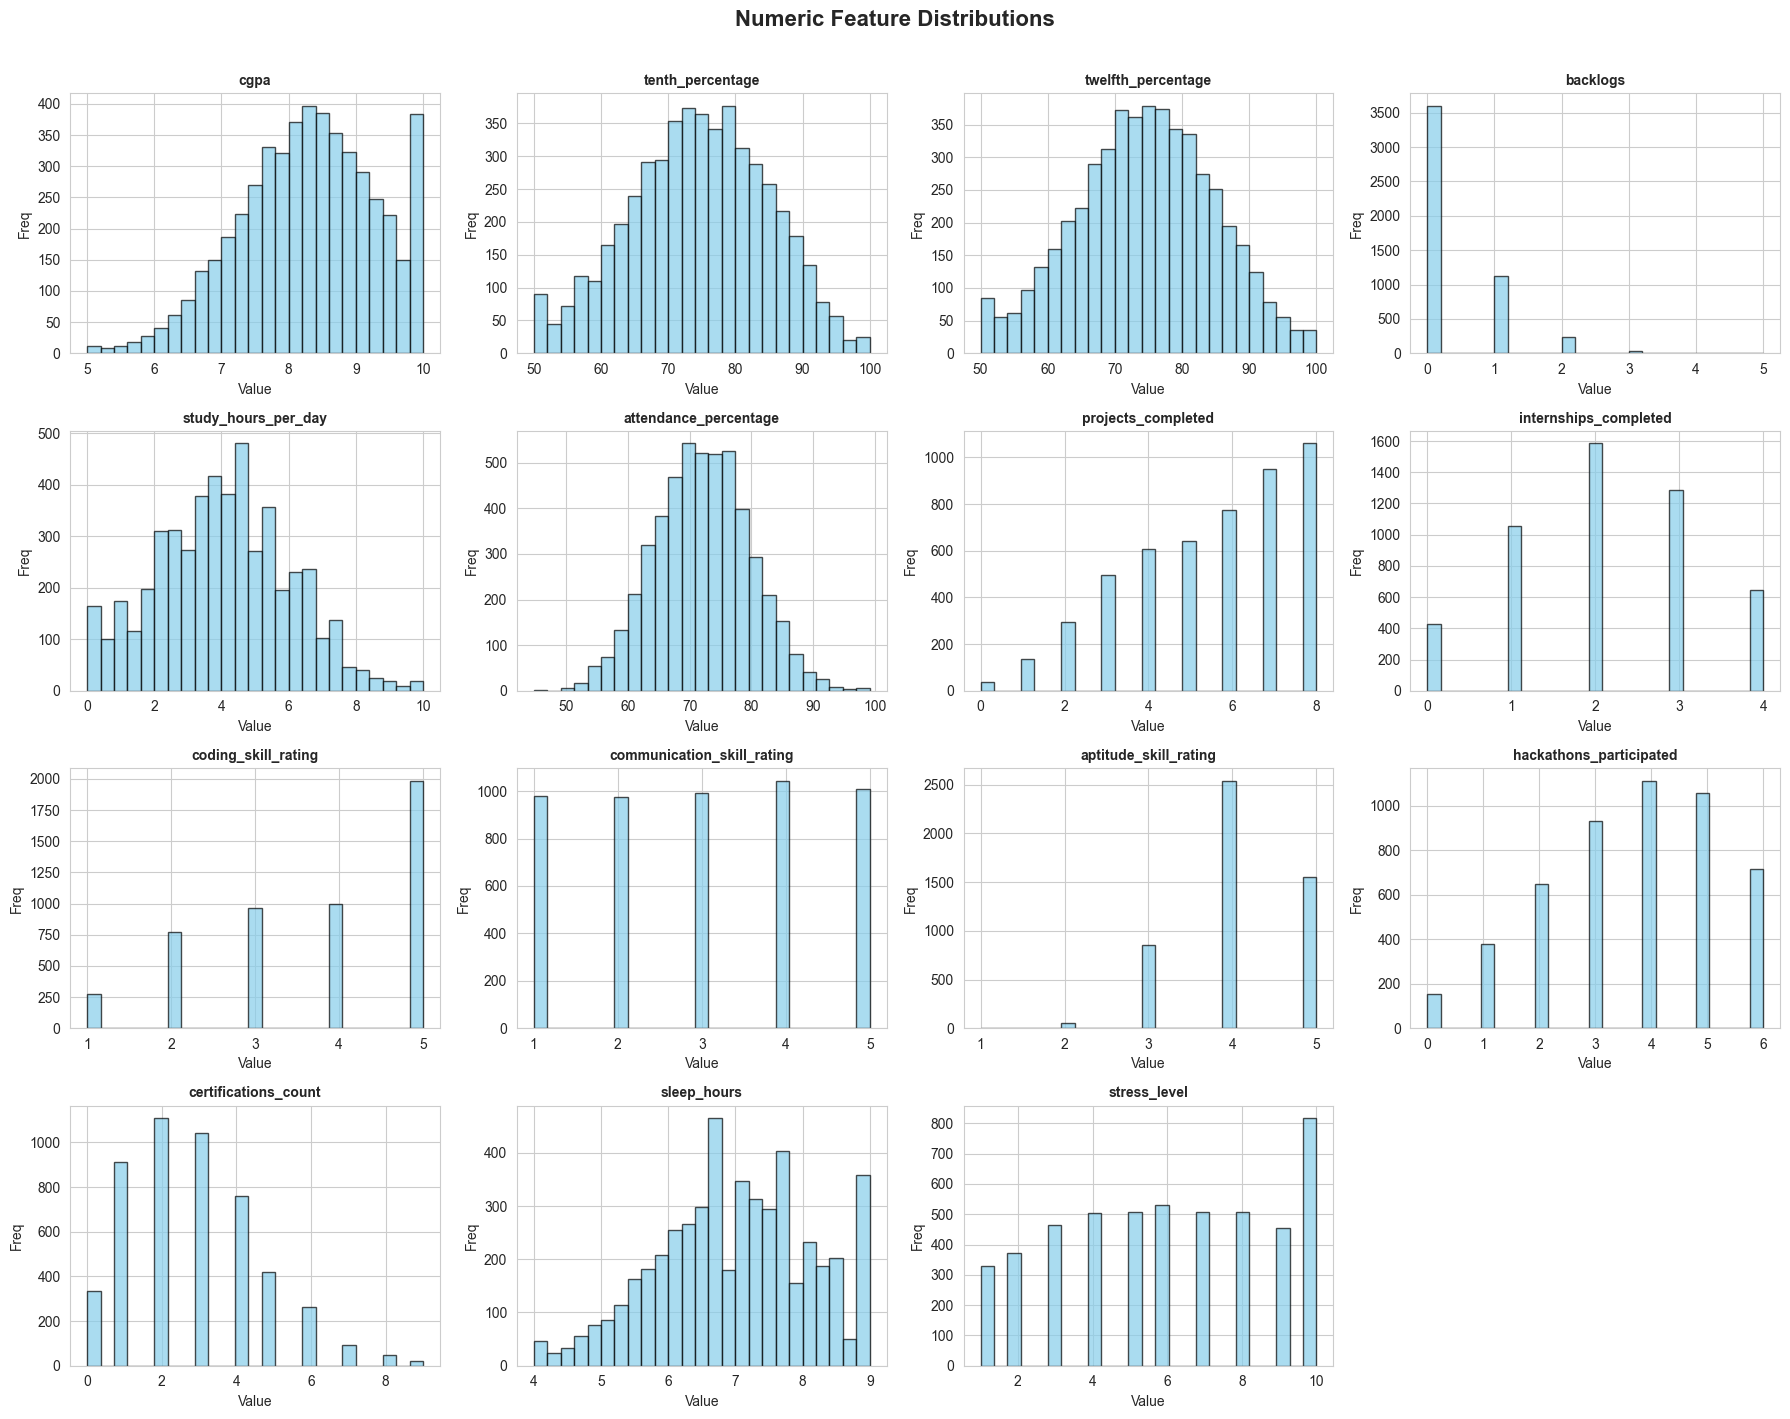

In [ ]:
# ========================================
# 6. FEATURE DISTRIBUTIONS (NUMERIC)
# ========================================
num_features = [c for c in numeric_cols if c not in ['placement_status', 'salary_lpa']]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.ravel()

for idx, feature in enumerate(num_features):
    if idx < len(axes):
        axes[idx].hist(df[feature], bins=25, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(feature, fontweight='bold', fontsize=10)
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Freq')

for idx in range(len(num_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

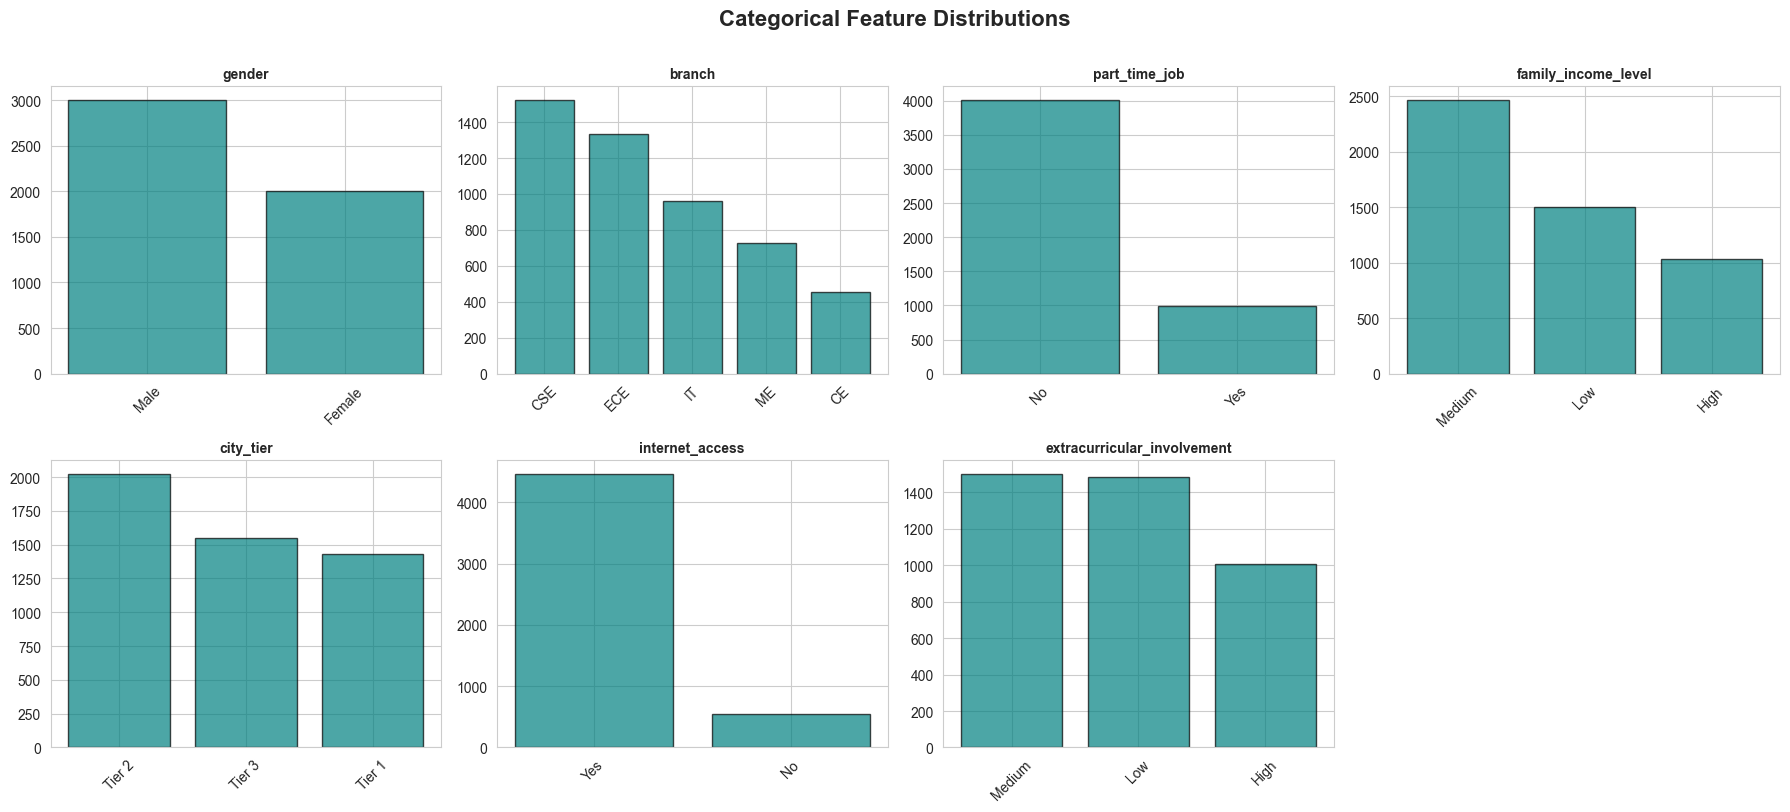

In [ ]:
# ========================================
# 6b. CATEGORICAL FEATURE DISTRIBUTIONS
# ========================================
cat_cols = ['gender', 'branch', 'part_time_job', 'family_income_level',
            'city_tier', 'internet_access', 'extracurricular_involvement']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[idx].bar(counts.index.astype(str), counts.values, color='teal', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontweight='bold', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(cat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Key Features vs Target
Membandingkan distribusi fitur penting berdasarkan status placement.

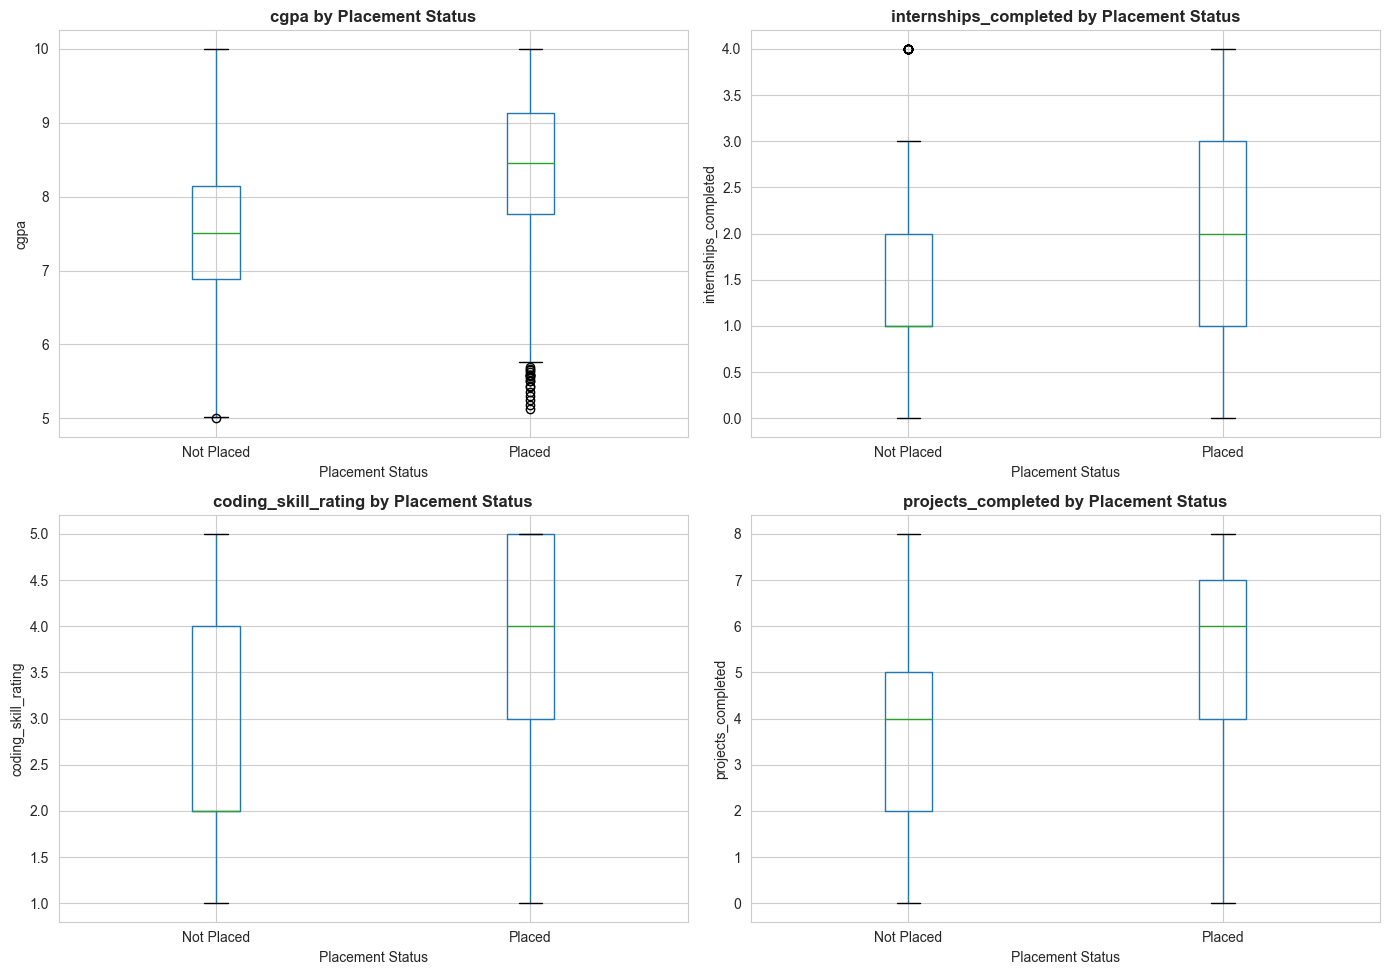

In [ ]:
# ========================================
# 7. KEY FEATURES vs PLACEMENT STATUS
# ========================================
key_features = ['cgpa', 'internships_completed', 'coding_skill_rating', 'projects_completed']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(key_features):
    row = idx // 2
    col = idx % 2
    df.boxplot(column=feature, by='placement_status', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Placement Status', fontweight='bold')
    axes[row, col].set_xlabel('Placement Status')
    axes[row, col].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.show()

## 8. Data Preprocessing
Langkah preprocessing meliputi:
1. Menangani missing values pada `extracurricular_involvement`
2. Menghapus kolom `Student_ID`
3. Encoding fitur kategorikal
4. Feature scaling
5. Train-test split (80:20)

In [11]:
# ========================================
# 8. DATA PREPROCESSING
# ========================================
print("\n" + "=" * 50)
print("DATA PREPROCESSING")
print("=" * 50)

# Handle missing values
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna('None')
print(f"Missing values after imputation: {df.isnull().sum().sum()}")

# Drop Student_ID
df = df.drop('Student_ID', axis=1)

# Define feature groups
nominal_cols = ['gender', 'branch', 'part_time_job', 'internet_access']
ordinal_cols = ['family_income_level', 'city_tier', 'extracurricular_involvement']

ordinal_order = [
    ['Low', 'Medium', 'High'],              # family_income_level
    ['Tier 3', 'Tier 2', 'Tier 1'],          # city_tier
    ['None', 'Low', 'Medium', 'High']        # extracurricular_involvement
]

# Separate features and targets
X = df.drop(['placement_status', 'salary_lpa'], axis=1)
y_cls = df['placement_status']      # Classification target
y_reg = df['salary_lpa']            # Regression target

# Encode classification target
le = LabelEncoder()
y_cls_encoded = le.fit_transform(y_cls)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Train-test split (80:20)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls_encoded, test_size=0.2, random_state=42, stratify=y_cls_encoded
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"\nClassification - Train: {X_train_cls.shape[0]}, Test: {X_test_cls.shape[0]}")
print(f"Regression     - Train: {X_train_reg.shape[0]}, Test: {X_test_reg.shape[0]}")

# Build preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),
        ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols)
    ],
    remainder='passthrough'
)

# Fit-transform on train, transform on test
X_train_cls_processed = preprocessor.fit_transform(X_train_cls)
X_test_cls_processed = preprocessor.transform(X_test_cls)

X_train_reg_processed = preprocessor.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor.transform(X_test_reg)

# Scale
scaler = StandardScaler()
X_train_cls_scaled = scaler.fit_transform(X_train_cls_processed)
X_test_cls_scaled = scaler.transform(X_test_cls_processed)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg_processed)
X_test_reg_scaled = scaler_reg.transform(X_test_reg_processed)

print("\nFeature scaling completed (StandardScaler)")
print("")


DATA PREPROCESSING
Missing values after imputation: 0
Label mapping: {'Not Placed': np.int64(0), 'Placed': np.int64(1)}

Classification - Train: 4000, Test: 1000
Regression     - Train: 4000, Test: 1000

Feature scaling completed (StandardScaler)



## 9. Classification Models
Membangun dan membandingkan 3 algoritma klasifikasi:
1. **Logistic Regression** - Baseline linear model
2. **Random Forest Classifier** - Ensemble bagging method
3. **Gradient Boosting Classifier** - Ensemble boosting method

Dipilih karena masing-masing mewakili pendekatan berbeda: linear, bagging, dan boosting. Kombinasi ini memberikan perspektif luas terhadap performa data.

In [12]:
# ========================================
# 9. CLASSIFICATION MODELS
# ========================================
print("\n" + "=" * 50)
print("CLASSIFICATION MODEL TRAINING")
print("=" * 50)

cls_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

cls_results = {}
cls_predictions = {}

for name, model in cls_models.items():
    model.fit(X_train_cls_scaled, y_train_cls)
    y_pred = model.predict(X_test_cls_scaled)
    cls_predictions[name] = y_pred

    accuracy = accuracy_score(y_test_cls, y_pred)
    precision = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_cls, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)

    cls_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    print(f"{name} - Accuracy: {accuracy:.4f} | F1: {f1:.4f}")

print("")


CLASSIFICATION MODEL TRAINING
Logistic Regression - Accuracy: 0.8900 | F1: 0.8805
Random Forest - Accuracy: 0.8940 | F1: 0.8782
Gradient Boosting - Accuracy: 0.8870 | F1: 0.8790



## 10. Classification Model Comparison


CLASSIFICATION MODEL COMPARISON

                      Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.890     0.8781   0.890    0.8805
Random Forest           0.894     0.8824   0.894    0.8782
Gradient Boosting       0.887     0.8759   0.887    0.8790


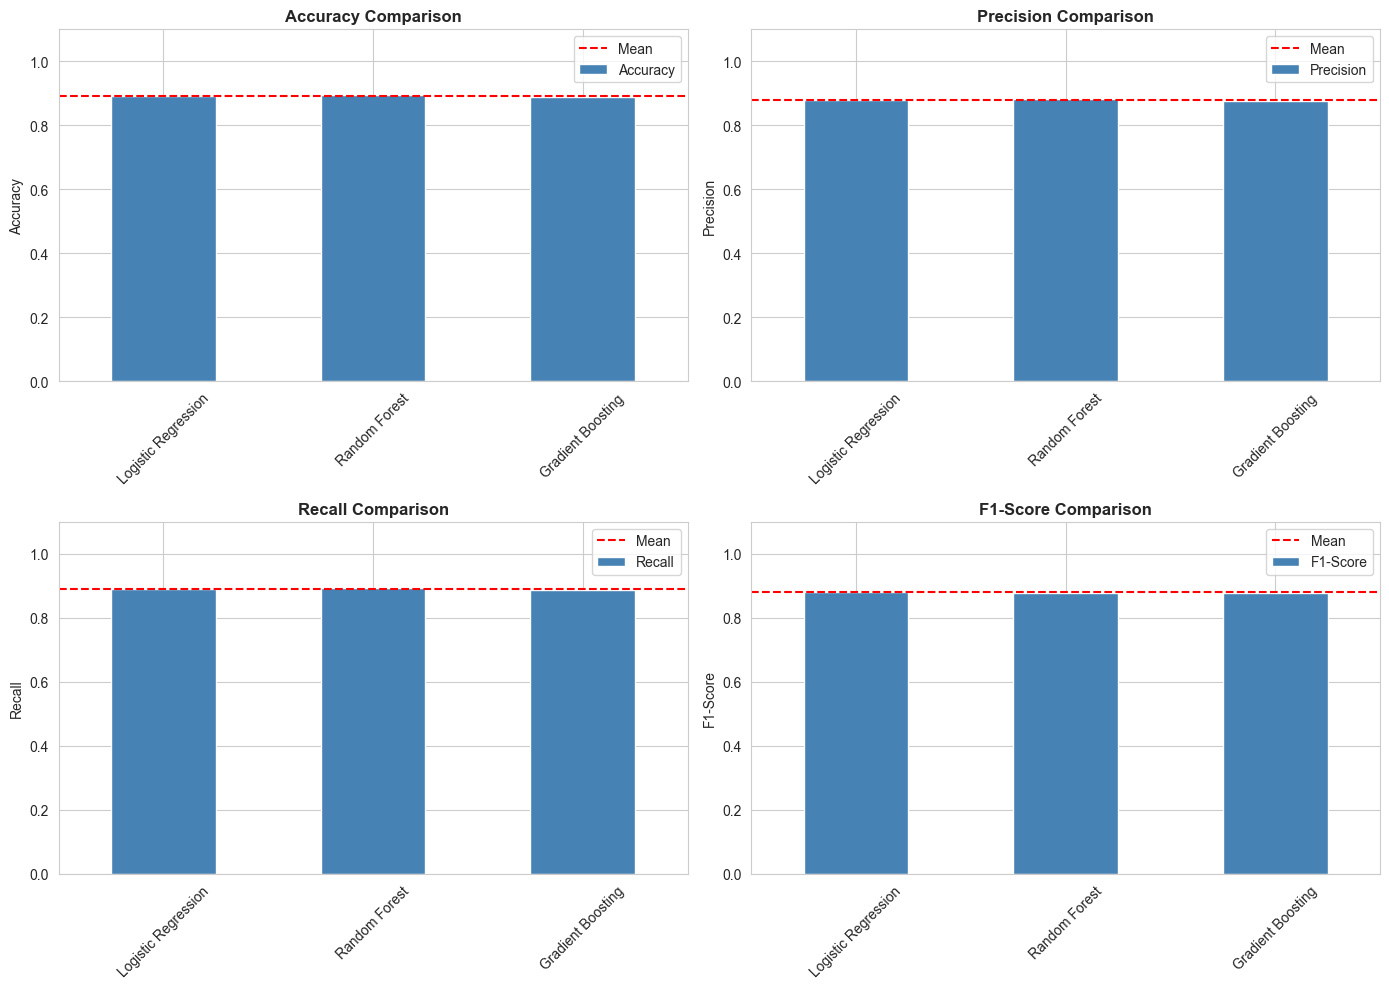

In [ ]:
# ========================================
# 10. CLASSIFICATION MODEL COMPARISON
# ========================================
print("\n" + "=" * 50)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 50)

cls_comparison = pd.DataFrame(cls_results).T.round(4)
print("\n", cls_comparison)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    cls_comparison[metric].plot(kind='bar', ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(f'{metric} Comparison', fontweight='bold')
    axes[row, col].set_ylabel(metric)
    axes[row, col].set_ylim([0, 1.1])
    axes[row, col].axhline(y=cls_comparison[metric].mean(), color='red',
                           linestyle='--', label='Mean')
    axes[row, col].legend()
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11. Confusion Matrices (Classification)


CONFUSION MATRICES


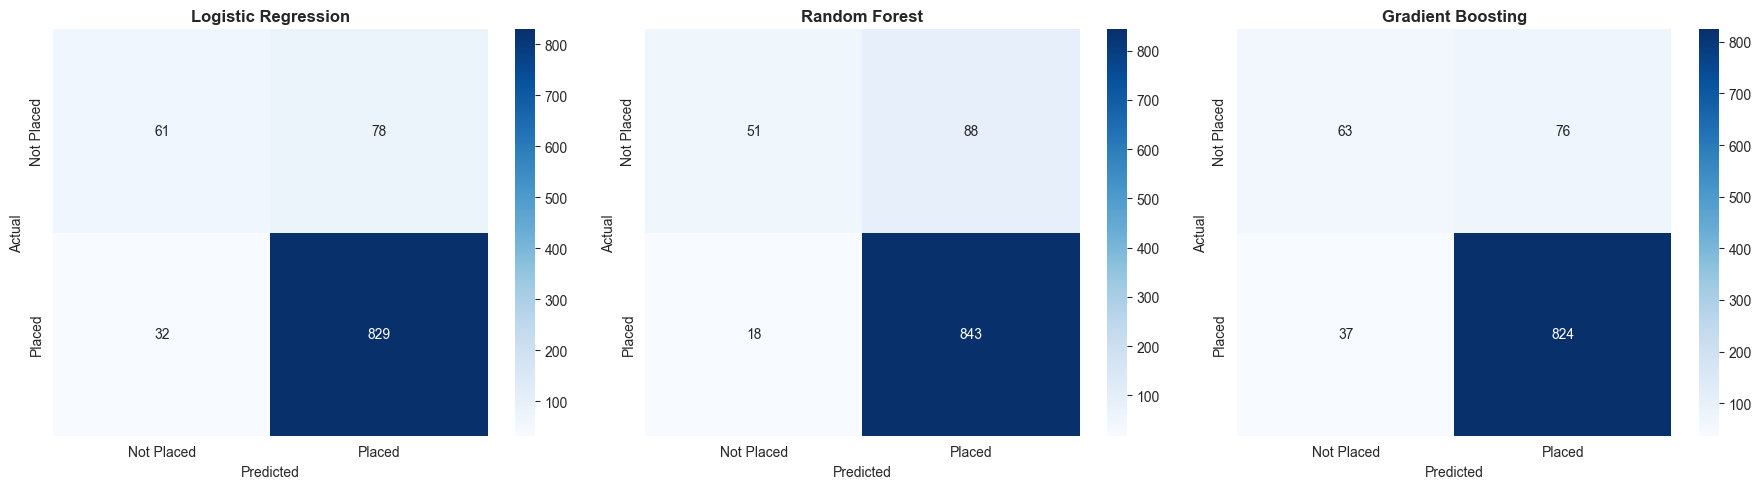

In [ ]:
# ========================================
# 11. CONFUSION MATRICES
# ========================================
print("\n" + "=" * 50)
print("CONFUSION MATRICES")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(cls_predictions.items()):
    cm = confusion_matrix(y_test_cls, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Placed', 'Placed'],
                yticklabels=['Not Placed', 'Placed'])
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 12. ROC-AUC Analysis (Classification)


ROC-AUC ANALYSIS
Logistic Regression - AUC: 0.9112
Random Forest - AUC: 0.9012
Gradient Boosting - AUC: 0.9045


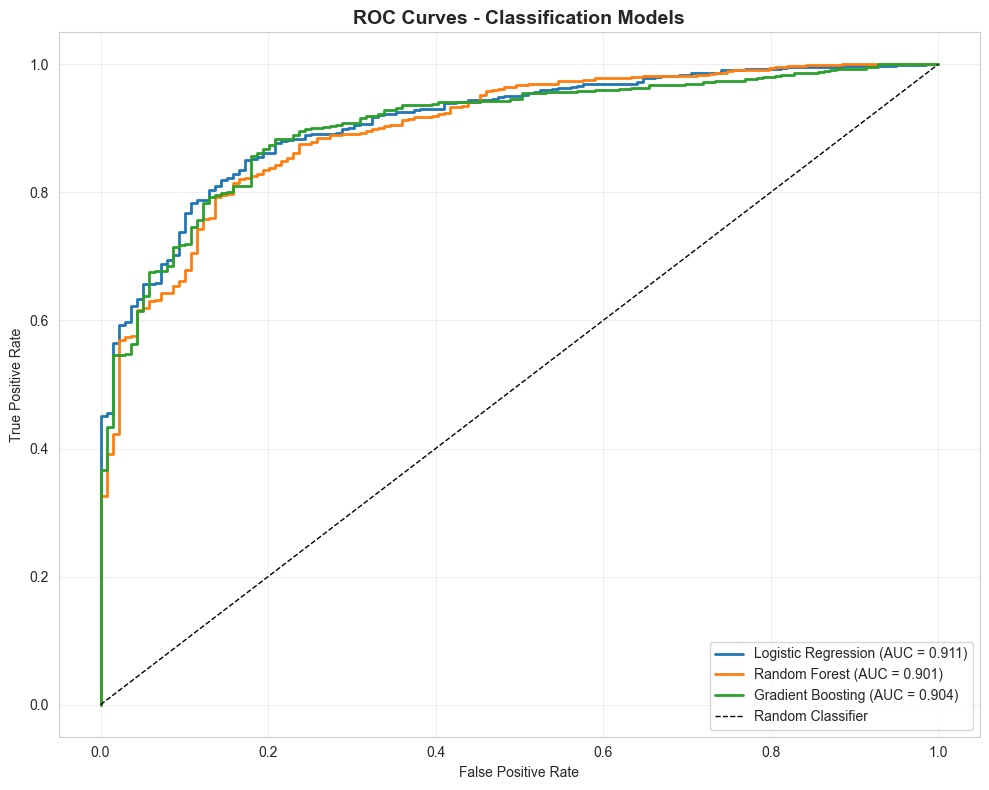

In [ ]:
# ========================================
# 12. ROC-AUC ANALYSIS
# ========================================
print("\n" + "=" * 50)
print("ROC-AUC ANALYSIS")
print("=" * 50)

plt.figure(figsize=(10, 8))

for name, model in cls_models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_cls_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_cls, y_proba)
        auc = roc_auc_score(y_test_cls, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
        print(f"{name} - AUC: {auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Classification Models', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Regression Models
Membangun dan membandingkan 3 algoritma regresi untuk prediksi `salary_lpa`:
1. **Linear Regression** - Baseline linear approach
2. **Random Forest Regressor** - Ensemble bagging
3. **Gradient Boosting Regressor** - Ensemble boosting

Metrik evaluasi: MSE, MAE, RMSE, dan R2 Score.

In [16]:
# ========================================
# 13. REGRESSION MODELS
# ========================================
print("\n" + "=" * 50)
print("REGRESSION MODEL TRAINING")
print("=" * 50)

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

reg_results = {}
reg_predictions = {}

for name, model in reg_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred = model.predict(X_test_reg_scaled)
    reg_predictions[name] = y_pred

    mse = mean_squared_error(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)

    reg_results[name] = {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'R2-Score': r2
    }

    print(f"{name} - R2: {r2:.4f} | RMSE: {rmse:.4f}")

print("")


REGRESSION MODEL TRAINING
Linear Regression - R2: 0.5966 | RMSE: 3.9642
Random Forest - R2: 0.5592 | RMSE: 4.1442
Gradient Boosting - R2: 0.6097 | RMSE: 3.8993



## 14. Regression Model Comparison


REGRESSION MODEL COMPARISON

                        MSE     MAE    RMSE  R2-Score
Linear Regression  15.7150  2.8517  3.9642    0.5966
Random Forest      17.1744  2.7875  4.1442    0.5592
Gradient Boosting  15.2042  2.6164  3.8993    0.6097


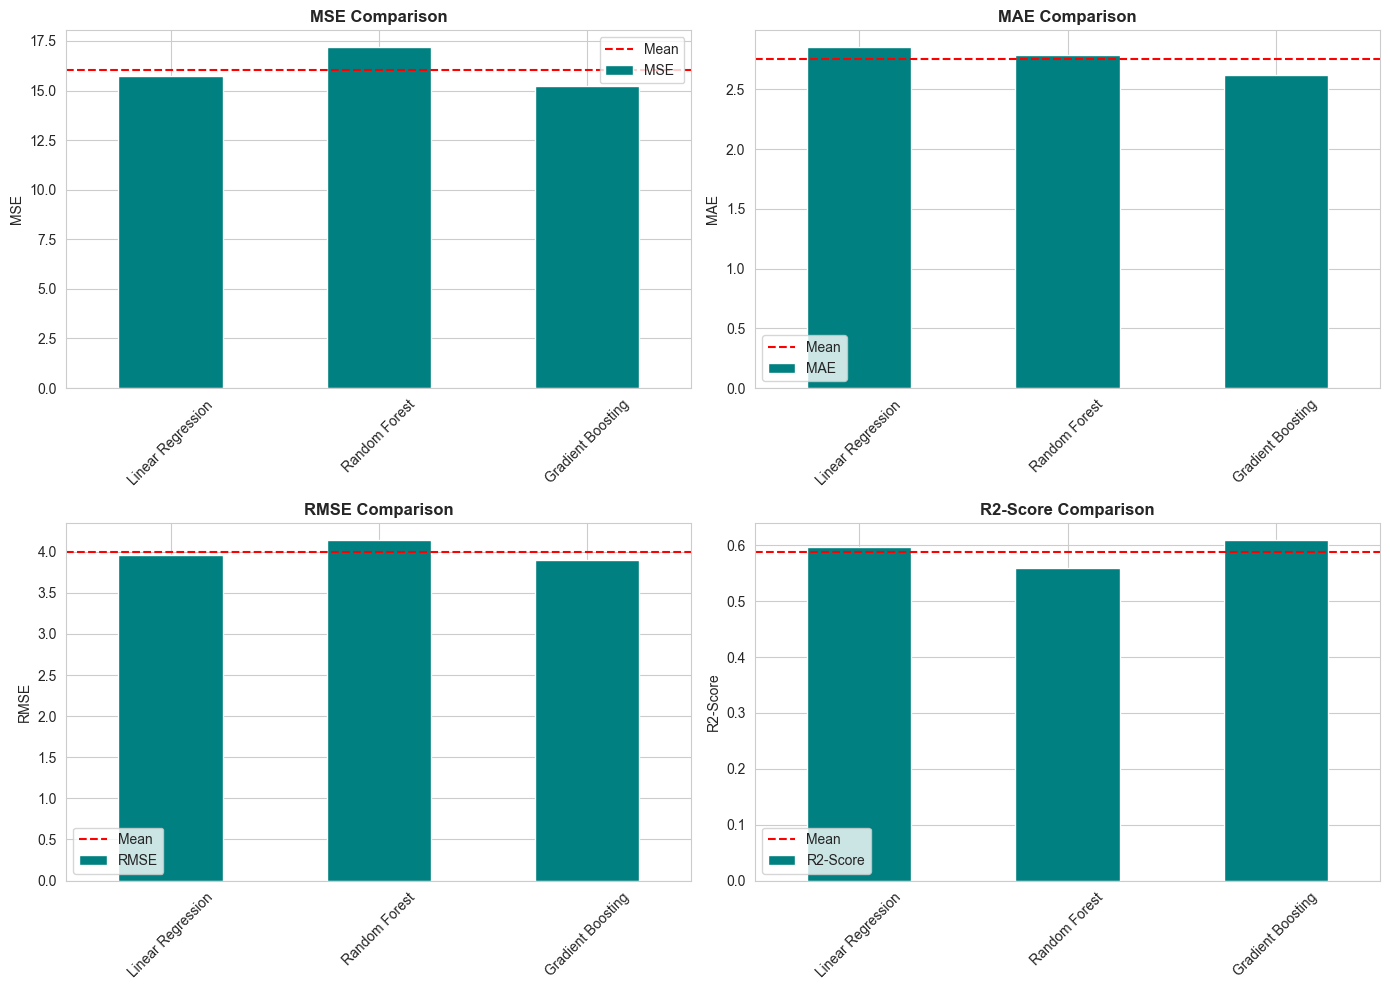

In [ ]:
# ========================================
# 14. REGRESSION MODEL COMPARISON
# ========================================
print("\n" + "=" * 50)
print("REGRESSION MODEL COMPARISON")
print("=" * 50)

reg_comparison = pd.DataFrame(reg_results).T.round(4)
print("\n", reg_comparison)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
reg_metrics = ['MSE', 'MAE', 'RMSE', 'R2-Score']

for idx, metric in enumerate(reg_metrics):
    row = idx // 2
    col = idx % 2
    reg_comparison[metric].plot(kind='bar', ax=axes[row, col], color='teal')
    axes[row, col].set_title(f'{metric} Comparison', fontweight='bold')
    axes[row, col].set_ylabel(metric)
    axes[row, col].axhline(y=reg_comparison[metric].mean(), color='red',
                           linestyle='--', label='Mean')
    axes[row, col].legend()
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 15. Actual vs Predicted (Regression)

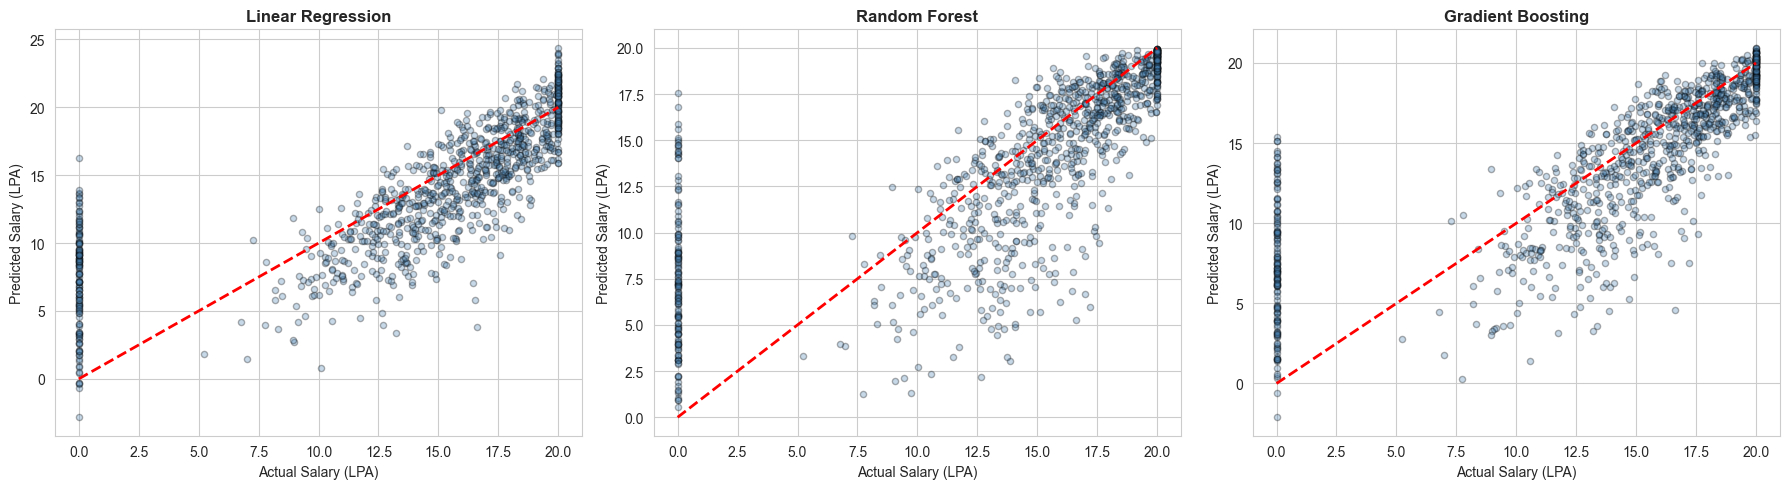

In [ ]:
# ========================================
# 15. ACTUAL vs PREDICTED SCATTER PLOTS
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(reg_predictions.items()):
    axes[idx].scatter(y_test_reg, y_pred, alpha=0.3, color='steelblue', edgecolor='black', s=20)
    axes[idx].plot([y_test_reg.min(), y_test_reg.max()],
                   [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Actual Salary (LPA)')
    axes[idx].set_ylabel('Predicted Salary (LPA)')

plt.tight_layout()
plt.show()

## 16. Feature Importance Analysis
Menggunakan model Random Forest (Classification) untuk melihat fitur yang paling berpengaruh terhadap prediksi.


FEATURE IMPORTANCE ANALYSIS

                         Feature  Importance
13                     backlogs    0.168796
10                         cgpa    0.092080
18          coding_skill_rating    0.088456
12           twelfth_percentage    0.072408
11             tenth_percentage    0.070489
16           projects_completed    0.065009
15        attendance_percentage    0.054767
14          study_hours_per_day    0.051363
23                  sleep_hours    0.049205
21      hackathons_participated    0.039668
17        internships_completed    0.039547
19   communication_skill_rating    0.033221
24                 stress_level    0.032038
22         certifications_count    0.027530
9   extracurricular_involvement    0.019300


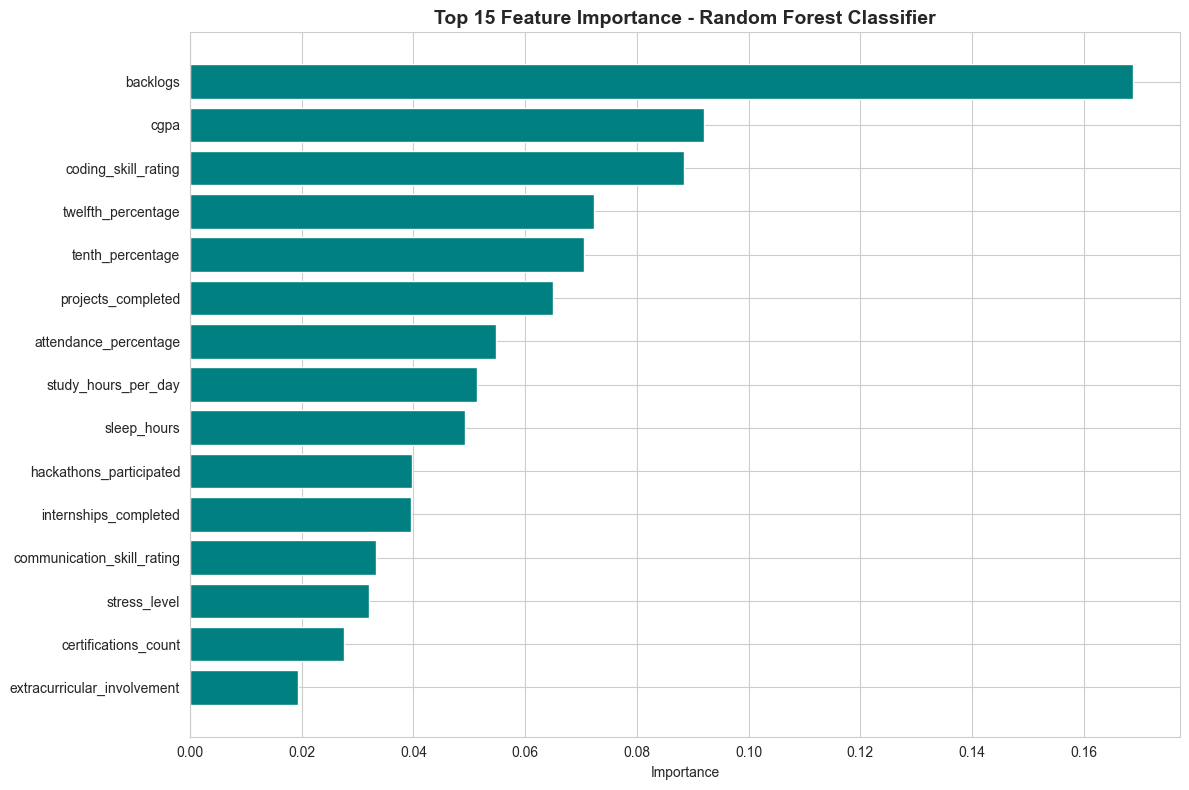

In [ ]:
# ========================================
# 16. FEATURE IMPORTANCE
# ========================================
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get feature names after preprocessing
onehot_features = preprocessor.named_transformers_['onehot'].get_feature_names_out(nominal_cols).tolist()
all_feature_names = onehot_features + ordinal_cols + [c for c in X.columns if c not in nominal_cols + ordinal_cols]

rf_cls = cls_models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_cls.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n", importance_df.head(15))

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'].head(15), importance_df['Importance'].head(15), color='teal')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance - Random Forest Classifier', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## 17. Save Best Models
Menyimpan model terbaik dalam format `.pkl` untuk digunakan pada tahap deployment.

In [20]:
# ========================================
# 17. SAVE BEST MODELS AS PIPELINE (.pkl)
# ========================================
print("\n" + "=" * 50)
print("SAVING BEST MODELS")
print("=" * 50)

# Build full pipeline for Classification (best: pick from results)
best_cls_name = cls_comparison['F1-Score'].idxmax()
print(f"Best Classification Model: {best_cls_name}")

cls_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', cls_models[best_cls_name])
])
cls_pipeline.fit(X_train_cls, y_train_cls)
joblib.dump(cls_pipeline, '../models/classification_pipeline.pkl')
print("Classification pipeline saved to ../models/classification_pipeline.pkl")

# Build full pipeline for Regression
best_reg_name = reg_comparison['R2-Score'].idxmax()
print(f"\nBest Regression Model: {best_reg_name}")

reg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', reg_models[best_reg_name])
])
reg_pipeline.fit(X_train_reg, y_train_reg)
joblib.dump(reg_pipeline, '../models/regression_pipeline.pkl')
print("Regression pipeline saved to ../models/regression_pipeline.pkl")

# Save label encoder
joblib.dump(le, '../models/label_encoder.pkl')
print("Label encoder saved to ../models/label_encoder.pkl")
print("")


SAVING BEST MODELS
Best Classification Model: Logistic Regression
Classification pipeline saved to ../models/classification_pipeline.pkl

Best Regression Model: Gradient Boosting
Regression pipeline saved to ../models/regression_pipeline.pkl
Label encoder saved to ../models/label_encoder.pkl



## 18. Results Summary

In [ ]:
# ========================================
# 18. RESULTS SUMMARY
# ========================================
print("\n" + "=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)

print("\n--- CLASSIFICATION ---")
print(f"Best Model: {best_cls_name}")
print(f"Accuracy : {cls_results[best_cls_name]['Accuracy']:.4f}")
print(f"Precision: {cls_results[best_cls_name]['Precision']:.4f}")
print(f"Recall   : {cls_results[best_cls_name]['Recall']:.4f}")
print(f"F1-Score : {cls_results[best_cls_name]['F1-Score']:.4f}")

print("\n--- REGRESSION ---")
print(f"Best Model: {best_reg_name}")
print(f"MSE     : {reg_results[best_reg_name]['MSE']:.4f}")
print(f"MAE     : {reg_results[best_reg_name]['MAE']:.4f}")
print(f"RMSE    : {reg_results[best_reg_name]['RMSE']:.4f}")
print(f"R2-Score: {reg_results[best_reg_name]['R2-Score']:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(f"\n{best_cls_name}:")
print(classification_report(y_test_cls, cls_predictions[best_cls_name],
                          target_names=['Not Placed', 'Placed']))


RESULTS SUMMARY

--- CLASSIFICATION ---
Best Model: Logistic Regression
Accuracy : 0.8900
Precision: 0.8781
Recall   : 0.8900
F1-Score : 0.8805

--- REGRESSION ---
Best Model: Gradient Boosting
MSE     : 15.2042
MAE     : 2.6164
RMSE    : 3.8993
R2-Score: 0.6097

CLASSIFICATION REPORT

Logistic Regression:
              precision    recall  f1-score   support

  Not Placed       0.66      0.44      0.53       139
      Placed       0.91      0.96      0.94       861

    accuracy                           0.89      1000
   macro avg       0.78      0.70      0.73      1000
weighted avg       0.88      0.89      0.88      1000

Results saved to CSV files.
